## E-commerce Customer Spending Analysis

### Objective

The goal of this project is to explore customer behavior data from an e-commerce platform and identify the factors that most strongly influence yearly customer spending.

Through exploratory data analysis and linear regression modeling, the project investigates relationships between customer engagement metrics, such as time spent on the website, time spent on the mobile app, and length of membership, and their impact on annual revenue generation.

The analysis aims to uncover meaningful business insights while applying practical machine learning techniques to customer data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
clientes = pd.read_csv("data/ecommerce-customers.csv")

In [3]:
clientes.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [4]:
clientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    str    
 1   Address               500 non-null    str    
 2   Avatar                500 non-null    str    
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), str(3)
memory usage: 31.4 KB


In [5]:
clientes.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


Relationship Between Time on Website and Yearly Amount Spent

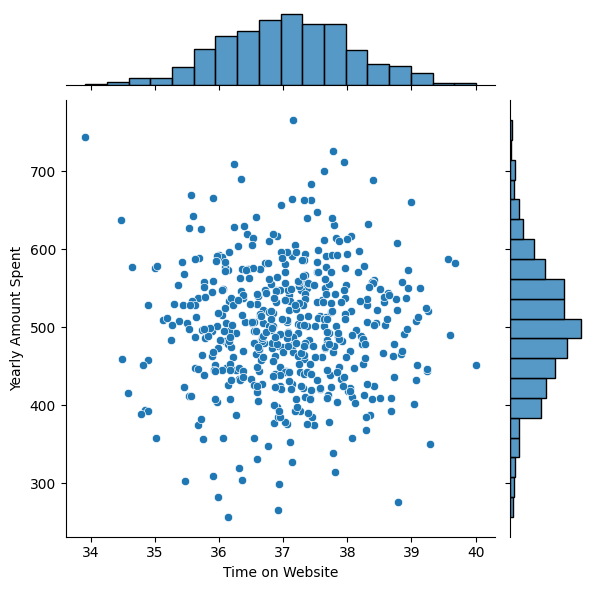

In [6]:
# Create jointplot
sns.jointplot(
    x="Time on Website",
    y="Yearly Amount Spent",
    data=clientes,
    kind="scatter"
)

plt.show()

- The jointplot suggests a mild positive relationship between Time on Website and Yearly Amount Spent.

- Customers who spend more time on the website tend to spend slightly more annually, although the relationship does not appear to be particularly strong.

- The data points are relatively dispersed, indicating that website usage alone may not be the main driver of customer spending.

Relationship Between Time on App and Yearly Amount Spent

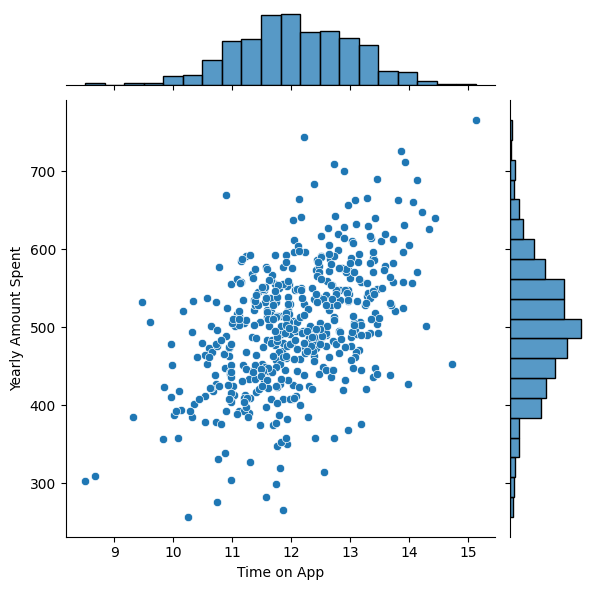

In [7]:
# Create jointplot
sns.jointplot(
    x="Time on App",
    y="Yearly Amount Spent",
    data=clientes,
    kind="scatter"
)

plt.show()

- The relationship between Time on App and Yearly Amount Spent appears stronger than the relationship observed with Time on Website.

- The data also shows a clearer positive trend, indicating that mobile app usage may be a stronger predictor of yearly revenue.

(This may suggest that improving the mobile app experience could have a stronger impact on customer spending than website engagement alone.)

2D hexbin plot comparing Time on App and Length of Membership

*This helps visualize where most customers are concentrated*

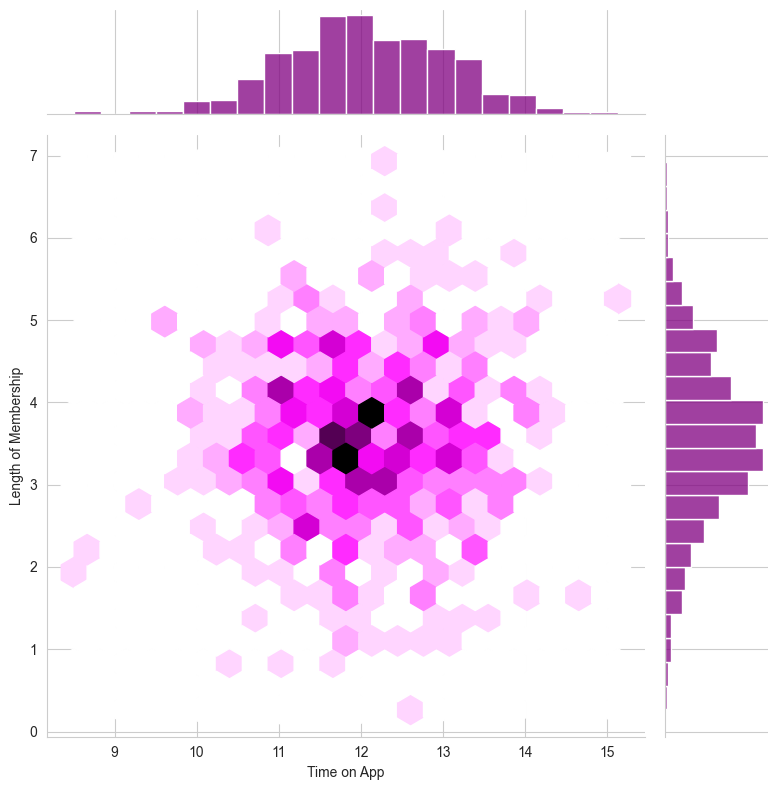

In [8]:
# Create 2D hexbin jointplot
sns.set_style("whitegrid")

sns.jointplot(
    x="Time on App",
    y="Length of Membership",
    data=clientes,
    kind="hex",
    height=8,
    color="purple"
)

plt.show()

- Most customers appear to be concentrated around average app usage and moderate membership duration. The plot does not suggest a very strong relationship between these two variables, indicating that time spent on the app and membership length may capture different aspects of customer behavior.

Pairwise Relationships Between Numerical Variables

*This helps visualize relationships and distributions across the dataset*

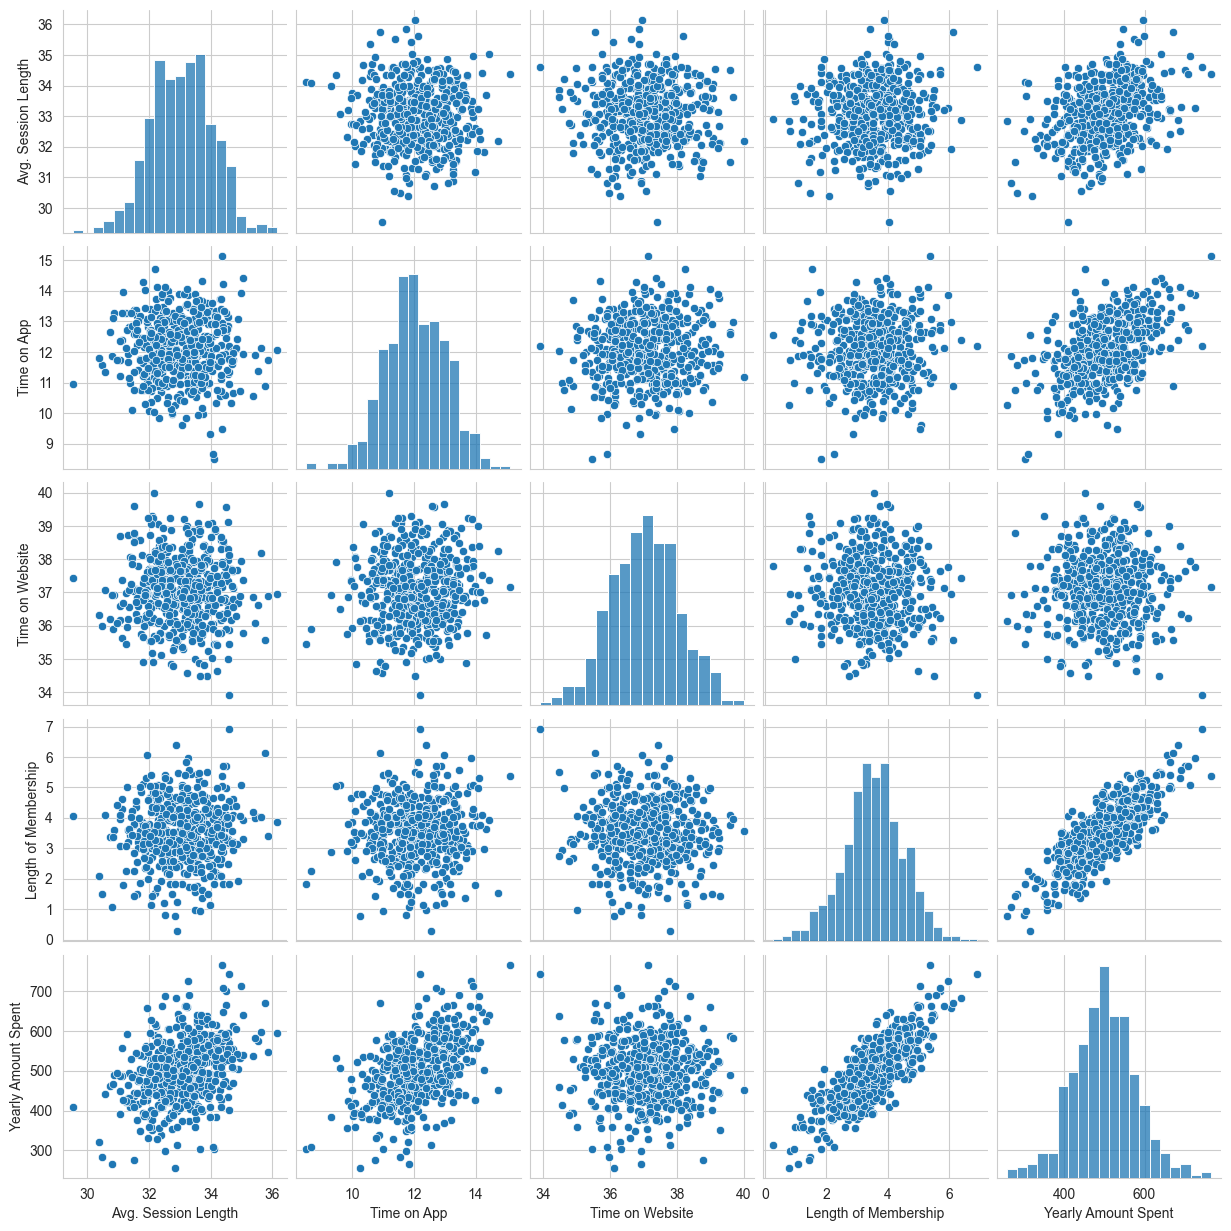

In [12]:
sns.set_style("whitegrid")

sns.pairplot(
    clientes,
    diag_kind="hist"
)

plt.show()

- Among all features, Length of Membership appears to have the strongest positive relationship with Yearly Amount Spent, suggesting that long-term customers tend to generate more revenue.

- Time on App also shows a moderate positive relationship with yearly spending, while Time on Website appears to have a weaker association.

- These patterns suggest that customer retention and app engagement may be more important drivers of revenue than website usage alone.

Linear Relationship Between Length of Membership and Yearly Amount Spent

*This helps visualize the relationship between membership duration and yearly spending*

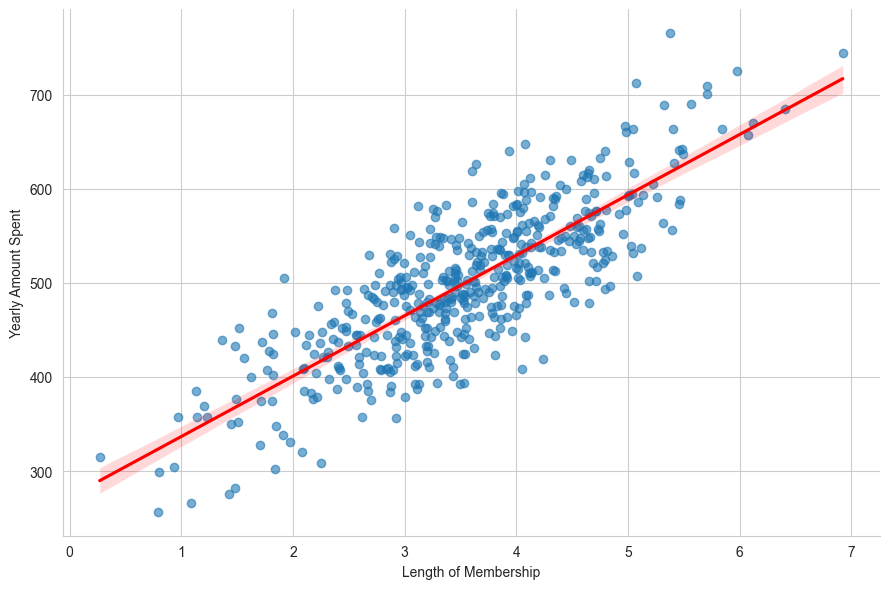

In [16]:
sns.set_style("whitegrid")

sns.lmplot(
    x="Length of Membership",
    y="Yearly Amount Spent",
    data=clientes,
    height=6,
    aspect=1.5,
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)

plt.show()

- The lmplot reveals a strong positive linear relationship between Length of Membership and Yearly Amount Spent.

- Customers with longer membership durations tend to spend significantly more annually, suggesting that customer retention is strongly associated with higher revenue generation.

- The data points generally follow the regression line closely, indicating that Length of Membership may be a strong predictor for a linear regression model.

--- 
### Preparing Data for Machine Learning

In [18]:
# Define feature variables (X)
# These are the numerical customer characteristics used for prediction
X = clientes[[
    "Avg. Session Length",
    "Time on App",
    "Time on Website",
    "Length of Membership"
]]

# Define target variable (y)
# This is the value we want to predict
y = clientes["Yearly Amount Spent"]

*X -> features (inputs)*

*Y -> target*

### Train-Test Split

In [19]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
# 70% of the data will be used for training
# 30% will be used for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=101
)

In [20]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (350, 4)
X_test shape: (150, 4)


In [21]:
from sklearn.linear_model import LinearRegression

# Create Linear Regression model instance
lm = LinearRegression()

# Train the model using the training data
lm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**Model Coefficients**



In [22]:
# Print model coefficients
coeff_df = pd.DataFrame(
    lm.coef_,
    X.columns,
    columns=["Coefficient"]
)

coeff_df

,Coefficient
Avg. Session Length,25.981550
Time on App,38.590159
Time on Website,0.190405
Length of Membership,61.279097


(↑ feature → ↑ spending)

The model coefficients suggest that Length of Membership has the strongest positive impact on yearly customer spending, reinforcing the patterns observed during the exploratory analysis.

### Predictions on Test Data

In [23]:
# Generate predictions using the test data
predictions = lm.predict(X_test)

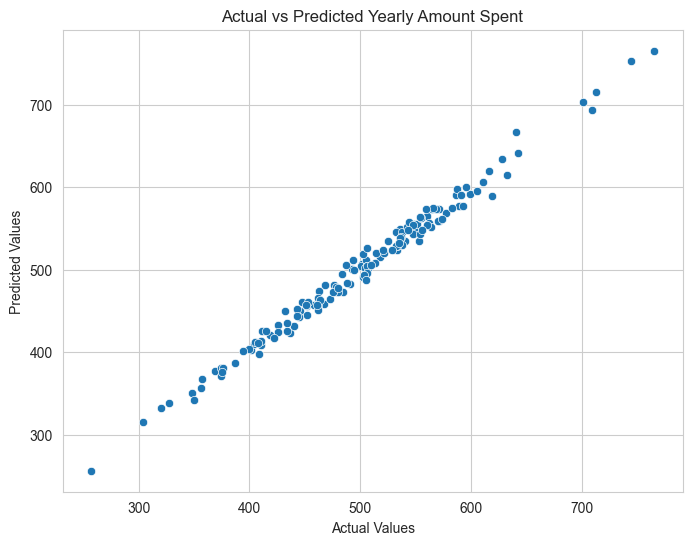

In [24]:
# Scatterplot of actual vs predicted values
# This helps evaluate how well the model predictions match the real values
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=predictions
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Yearly Amount Spent")

plt.show()

- The scatterplot shows a strong alignment between actual and predicted values, suggesting that the Linear Regression model performs well in predicting yearly customer spending.

- Most points are concentrated near the diagonal trend, indicating relatively small prediction errors and a good linear fit.

### Model Evaluation Metrics

In [25]:
from sklearn import metrics
import numpy as np

# Calculate evaluation metrics
mae = metrics.mean_absolute_error(y_test, predictions)
mse = metrics.mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

# Print results
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

MAE: 7.228148653430826
MSE: 79.81305165097427
RMSE: 8.933815066978624


- The evaluation metrics indicate that the Linear Regression model performs well in predicting yearly customer spending.

- The relatively low error values and the strong alignment between actual and predicted values suggest that the selected features capture meaningful patterns in customer behavior.

### Residual Distribution

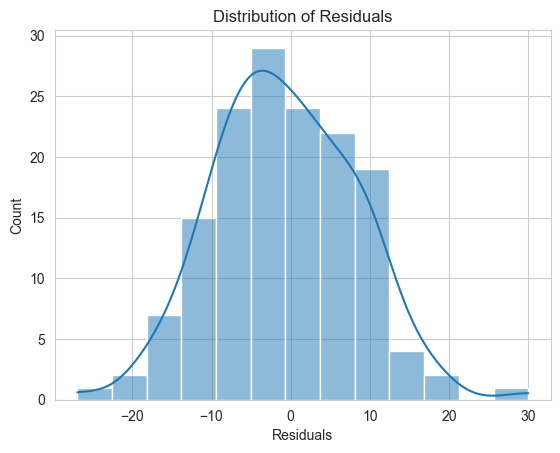

In [26]:
# Calculate residuals
residuals = y_test - predictions

# Plot residual distribution
sns.histplot(
    residuals,
    kde=True
)

plt.title("Distribution of Residuals")
plt.xlabel("Residuals")

plt.show()

- The residual distribution appears approximately normal and centered around zero, suggesting that the Linear Regression model provides a reasonable fit for the data.

- No major patterns or strong asymmetries are visible, indicating that the model errors are relatively random.

---

## Conclusion

The analysis suggests that Length of Membership is the strongest predictor of Yearly Amount Spent, indicating that long-term customers tend to generate significantly more revenue.

Although Time on App showed a stronger relationship with yearly spending than Time on Website, the difference does not appear large enough to conclude that the company should focus exclusively on the mobile app experience.

Overall, customer retention seems to play a more important role than platform preference alone. This suggests that strategies focused on increasing customer loyalty and long-term engagement may have the greatest impact on revenue growth.

The Linear Regression model performed well and the residual analysis indicated a reasonable fit, showing that the selected features capture meaningful patterns in customer behavior.